In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import torch
import numpy as np
import matplotlib.pyplot as plt
import yaml

from src.models.model import LitS4DenoisingModel
from src.models.networks import S4DSeq2SeqModel
from src.data.data import LitDenoisingDataModule

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interpn

/n/home07/hbinney/.conda/envs/ssm_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


In [2]:
# Detection efficiency
efficiency_file = np.load("epsilon_grid.npz")
efficiency_energies = efficiency_file['energies']
efficiency_pitches = efficiency_file['pitches']
efficiency_radii = efficiency_file['radii']
efficiency_grid = np.squeeze(efficiency_file['epsilon'][4, :, :, :]) #~9 sigma threshold
efficiency_grid_onenergy = np.squeeze(efficiency_grid[0, :, :]) # about the same for each energy, so don't worry about the energy dependence for now 
# grid is defined for a different range than the SSM simulations

Text(0.5, 1.0, 'Detection efficiency with 9 sigma threshold')

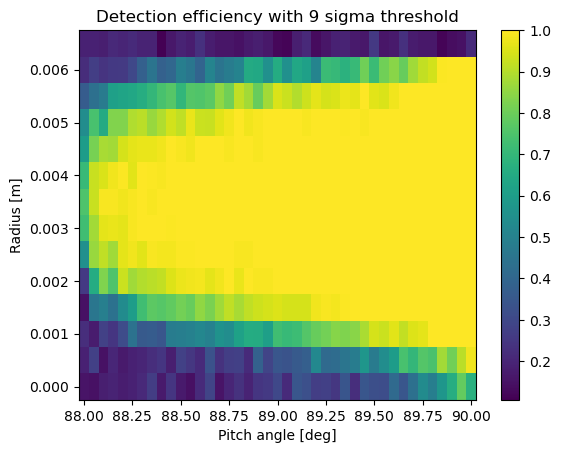

In [3]:
plt.pcolormesh(efficiency_pitches, efficiency_radii, np.transpose(efficiency_grid_onenergy))
plt.xlabel("Pitch angle [deg]")
plt.ylabel("Radius [m]")
plt.colorbar()
plt.title("Detection efficiency with 9 sigma threshold", fontsize=12)

In [4]:
# define pdf functions
# radial pdf
Rmax = 0.0065  # maximum active radius in metres
rs = np.linspace(0, Rmax, 14)

pdf_r = 2 * rs / Rmax**2          # f_r(r) = 2r / R_max^2
pdf_r = pdf_r 

# pitch angle pdf 
pitch_file = np.load("pitch_pdf.npy")
thetas = pitch_file[0]
pdf_theta = pitch_file[1]
pdf_theta = pdf_theta

# energy pdf - flat
# unnormalized for now
E_min = 18500
E_max = 18700
Es = np.linspace(E_min, E_max, 10)
pdf_E = np.ones(len(Es))
pdf_E = pdf_E / np.trapz(pdf_E, Es) # normalize properly

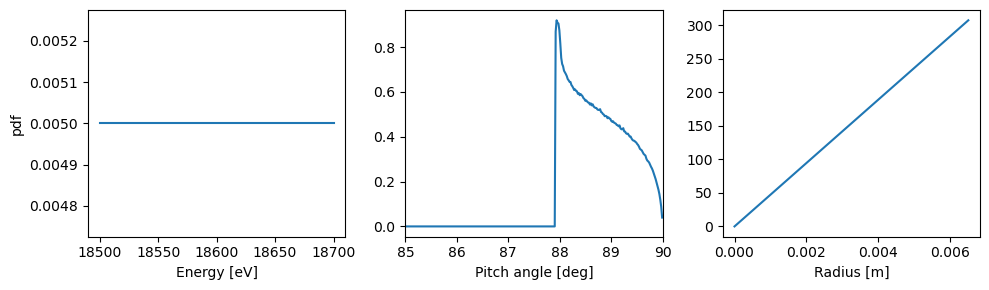

In [5]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(10, 3))
axs[0].plot(Es, pdf_E)
axs[0].set_xlabel("Energy [eV]")
axs[0].set_ylabel("pdf")
axs[1].plot(thetas, pdf_theta)
axs[1].set_xlim(85, 90)
axs[1].set_xlabel("Pitch angle [deg]")
axs[2].plot(rs, pdf_r)
axs[2].set_xlabel("Radius [m]")
plt.tight_layout()

Text(0, 0.5, 'Radius [m]')

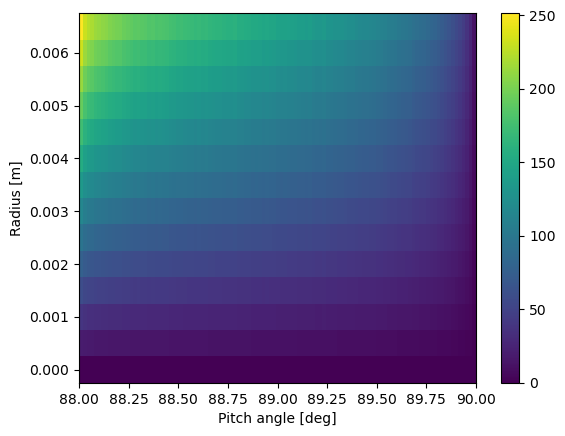

In [6]:
theta_mask = thetas > 88 
thetas_nonzero = thetas[theta_mask]
X, Y = np.meshgrid(thetas_nonzero, rs)
pdf_theta_nonzero = pdf_theta[theta_mask]
Z = pdf_r[:, None] * pdf_theta_nonzero[None, :]
coords = [(t, r) for t, r in zip(thetas_nonzero, rs)]
plt.pcolormesh(thetas_nonzero, rs, Z)#*efficiencies_interp)
plt.xlim(88, 90)
plt.colorbar()
plt.xlabel("Pitch angle [deg]")
plt.ylabel("Radius [m]")